In [1]:
import logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import sys
sys.path.append('.')

from utils import *
from experiment import *
from dataloader.vlfc import COMPANIES
from visualize import *

# Quick start with a single experiment

We start with runing a single time series forecasting experiment. We will run return forecasting problem on AMD stock return with baseline adapative conformal inference (ACI) methods.

### Load the hyper parameters of the model

The first step is to load the config file in `bellman-conformal-inference/config`.

In [2]:
params = read_yaml('config/rtfc-aci-AMD.yaml')

The naming of the config file follows the convention of `TASK_NAME-METHOD_NAME-TASK_DATASET.yaml`. In this case, the config file looks like

```
> params

{'task': 'rtfc',        # the return forecasting problem, avalibale choices ['rtfc', 'vlfc']
 'method': 'aci',       # the adapative conformal algorithm to use. 'aci' means baseline Adapative Conformal Algorithm
 'id': 'AMD',           # the dataset to be used by the experiment. They can be found in 'data/'
 'alpha0': 0.1,         # target miscoverage rate. In this case 10%
 'gamma': 0.1,          # step size for either ACI or BCI
 'lambda_init': 0.9,
 'lambda_max': 1.0,
 'lambda_min': 0.0}
```

We can run the experiment by using the `.run()` method, which captures all the details of computing $\alpha_t$ for each $t$. To hack around the code, please see `experiment.py` for the logic of computing $\alpha_t$.

### Build the experiment object and run the experiment

The experiment object created by

In [3]:
exp = ForecastingExperiment(params)

In [4]:
exp.run()

2026-01-21 13:30:25,551 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED
2026-01-21 13:30:30,711 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 ENDED in 5.159693002700806s


After we run the experiment, we can optionally save the experiment. They will be saved in `bellman-conformal-inference/result/*`. This include the full trajectory of the experiment, and the hyper parameter used.

In [5]:
exp.save()

Finally, we can visualize the experiment by calling the `visualize_single_exp(**)` function defined in `bellman-conformal-inference/visualize.py`.

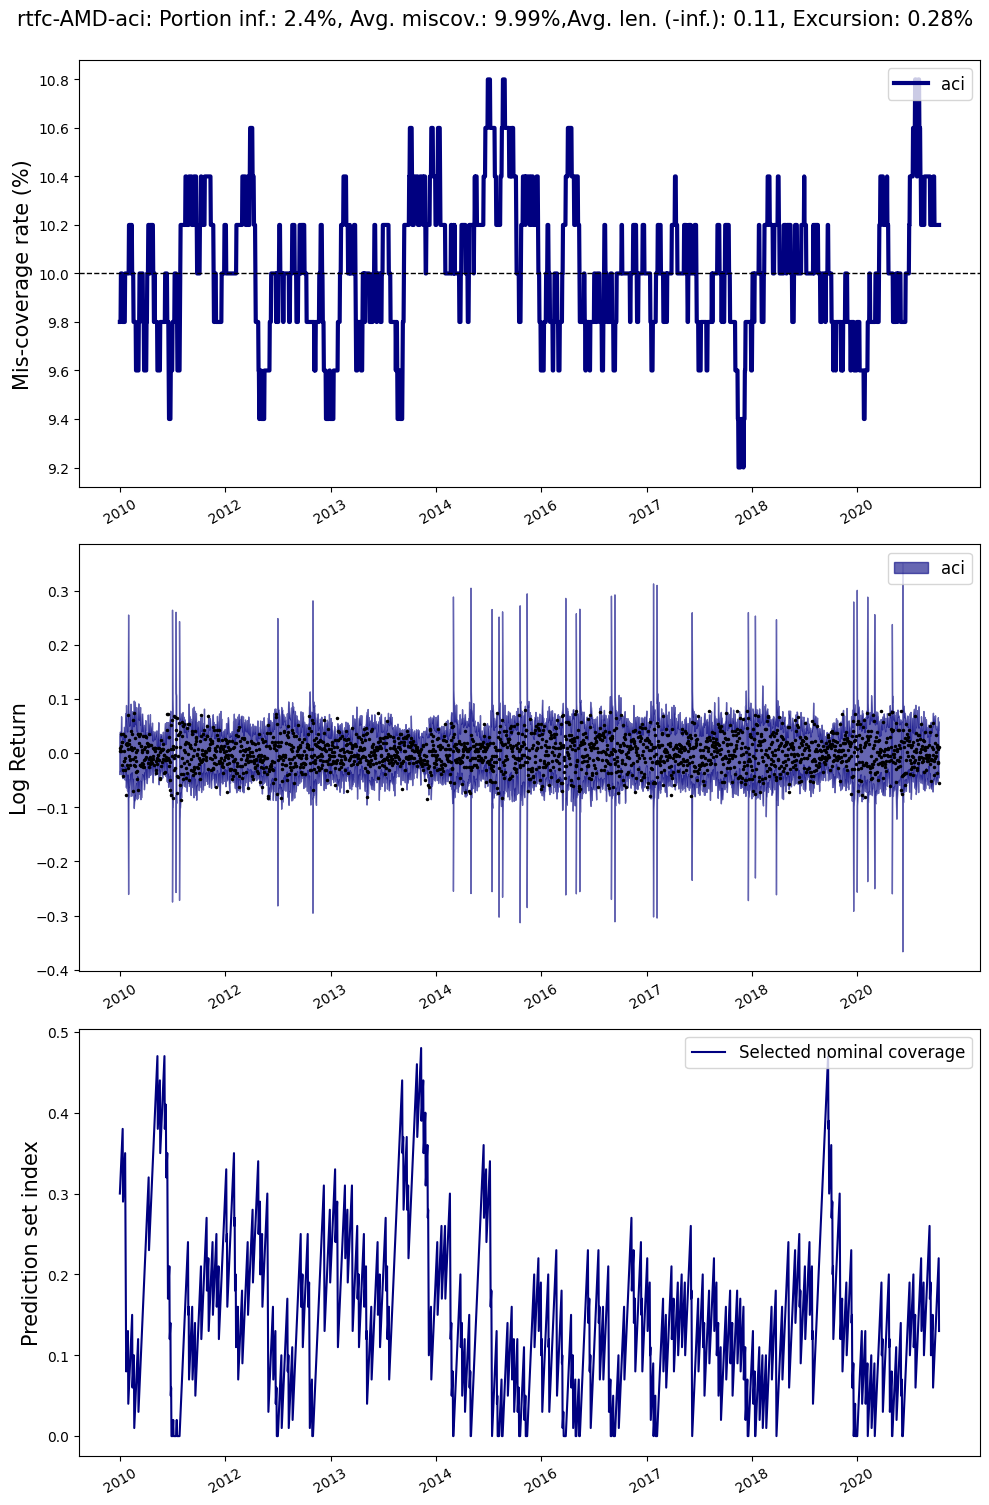

In [6]:
visualize_single_exp(exp.params, exp.result)

# Comparsion of three experiments

Next we demonstrate how to compare performance across three methods -- ACI, BCI, fixed $\alpha_t$ for the same experiment.

In [7]:
exp_aci = ForecastingExperiment(read_yaml('config/rtfc-aci-AMD.yaml'))
exp_aci.run()

exp_bci = ForecastingExperiment(read_yaml('config/rtfc-bci-AMD.yaml'))
exp_bci.run()

exp_fixed = ForecastingExperiment(read_yaml('config/rtfc-fixed-AMD.yaml'))
exp_fixed.run()

2026-01-21 13:30:33,344 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED
2026-01-21 13:30:38,711 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 ENDED in 5.366286754608154s
2026-01-21 13:30:38,739 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 STARTED
2026-01-21 13:30:57,458 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 ENDED in 18.718008756637573s
2026-01-21 13:30:57,506 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA STARTED
2026-01-21 13:31:07,353 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA ENDED in 9.846394777297974s


As before, we can visualize the comparsion as `visualize_three_exp`. In contrast to the previous plot, the figure first panel is the moving average mis-coverage rate, and the bottom panel is the moving average of interval length. The performance metric is given in the title of the plot:

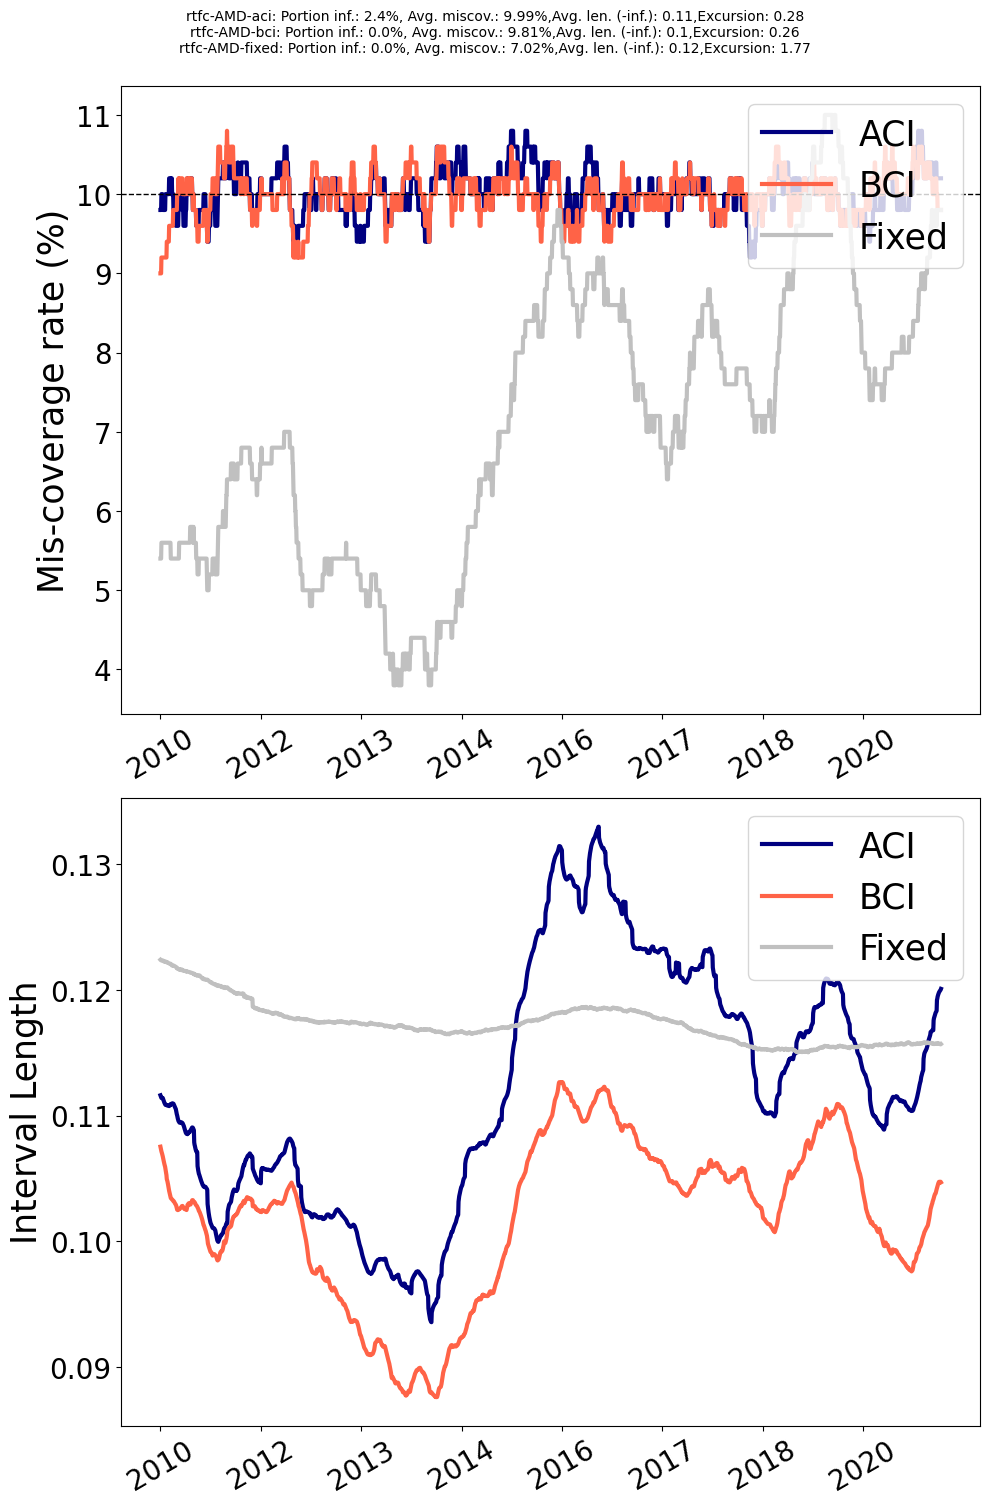

In [8]:
visualize_three_exp(exp_aci.params, exp_aci.result,
                    exp_bci.params, exp_bci.result,
                    exp_fixed.params, exp_fixed.result)

In [9]:
# begin with replicating plots from PID

import os
import numpy as np
import pandas as pd
import copy
from statsmodels.tsa.api import ExponentialSmoothing
from statsmodels.tsa.forecasting.theta import ThetaModel
from tqdm import tqdm
import pdb
import warnings




In [10]:
df_deaths = pd.read_csv('datasets/deaths.csv')
df_preds = pd.read_csv('datasets/preds_deaths.csv')

In [13]:
import pid_methods
import pid_base_plots

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
Y = df_deaths['deaths'].values
Y_hat = df_preds['0'].values

# 2. Run the PID Control Method
# ---------------------------------------------------------
# CRITICAL: Check your 'pid_methods.py' file.
# The function might be named 'run_pid_control', 'pid', or similar.
# The arguments usually include (y, y_hat, alpha, kp, ki, kd).
# ---------------------------------------------------------
alpha = 0.1 # 90% confidence
results = pid_methods.run_pid_control(
    y_true=Y, 
    y_pred=Y_hat, 
    alpha=alpha,
    kp=0.1,  # Proportional gain (Baseline)
    ki=0.1,  # Integral gain (Baseline)
    kd=0.0   # Derivative gain (Baseline)
)

# 3. Generate the Baseline Plot
# This uses your pid_base_plots.py (which uses plotting_utils.py)
pid_base_plots.plot_results(
    y_true=Y,
    y_pred=Y_hat,
    results=results, # or pass q_t/err_t separately depending on the function
    title="Baseline: Conformal PID (Deaths)"
)

plt.show()

NameError: name 'df_deaths' is not defined

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from visualize import gen_plot_data, PLOT_PARAM

def visualize_comparison_with_pid(aci_res, bci_res, fixed_res, pid_res, 
                                  aci_params, bci_params, fixed_params, pid_params,
                                  title="Comparison with Conformal PID"):
    
    fig, axs = plt.subplots(2, 1, figsize=(12, 12))
    
    experiments = [
        {'data': aci_res, 'params': aci_params, 'label': 'ACI', 'color': 'navy'},
        {'data': bci_res, 'params': bci_params, 'label': 'BCI', 'color': 'tomato'},
        {'data': fixed_res, 'params': fixed_params, 'label': 'Fixed', 'color': 'silver'},
        {'data': pid_res, 'params': pid_params, 'label': 'Conformal PID', 'color': 'green'}
    ]
    
    task = aci_params['task']
    ma_window = PLOT_PARAM['ma_window'][task]
    xstick_skip = PLOT_PARAM['xstick_skip'][task]
    xform = PLOT_PARAM['xform'][task]
    
    for exp in experiments:
        plotDt = gen_plot_data(exp['data'], ma_window, xstick_skip, xform)
        
        axs[0].plot(100 * plotDt['miscovrate'], '-', 
                    color=exp['color'], label=exp['label'], linewidth=2)
        
        axs[1].plot(plotDt['length'], '-', 
                    color=exp['color'], label=exp['label'], linewidth=2)
        
        indices = plotDt['indices']
        date_indices = plotDt['date_indices']

    axs[0].axhline(y=10, color='black', linestyle='--', linewidth=1, label='Target (10%)')
    axs[0].set_ylabel('Mis-coverage rate (%)', fontsize=16)
    axs[0].legend(loc='upper right', fontsize=14)
    axs[0].set_title(title, fontsize=18)
    axs[0].set_xticks(indices)
    axs[0].set_xticklabels([date_indices[i] for i in indices], rotation=30, fontsize=12)
    
    axs[1].set_ylabel('Interval Length', fontsize=16)
    axs[1].legend(loc='upper right', fontsize=14)
    axs[1].set_xticks(indices)
    axs[1].set_xticklabels([date_indices[i] for i in indices], rotation=30, fontsize=12)
    
    plt.tight_layout()
    return fig

In [14]:
import pandas as pd
import numpy as np
from utils import read_yaml
from pid_methods import quantile_integrator_log 

# --- 1. Define the PID Adapter Function ---
def run_pid_experiment(exp_fixed_result, alpha=0.1, lr=0.05, t_burnin=50):
    y_true = exp_fixed_result['true_y'].values
    y_pred_center = (exp_fixed_result['upper'].values + exp_fixed_result['lower'].values) / 2
    scores = np.abs(y_true - y_pred_center)
    
    # Using GOOGL parameters as proxy for AMD (KI=100, Csat=0.1)
    pid_out = quantile_integrator_log(
        scores=scores, 
        alpha=alpha, 
        lr=lr,
        Csat=0.1,    
        KI=100.0,    
        ahead=1, 
        T_burnin=t_burnin
    )
    
    pid_qs = pid_out['q']
    new_upper = y_pred_center + pid_qs
    new_lower = y_pred_center - pid_qs
    
    df_pid = exp_fixed_result.copy()
    df_pid['upper'] = new_upper
    df_pid['lower'] = new_lower
    df_pid['alpha'] = alpha
    
    # Create binary 'beta' for BCI visualizer compatibility
    is_covered = (df_pid['true_y'] >= df_pid['lower']) & (df_pid['true_y'] <= df_pid['upper'])
    df_pid['beta'] = is_covered.astype(int) 
    
    params_pid = {'method': 'PID', 'task': 'rtfc', 'id': 'PID', 'alpha0': alpha}
    return params_pid, df_pid

# --- 2. Run Original Experiments (USING YOUR YAML CONFIGS) ---
# This ensures ACI and BCI look exactly like they did in your good screenshots
exp_aci = ForecastingExperiment(read_yaml('config/rtfc-aci-AMD.yaml'))
exp_aci.run()

exp_bci = ForecastingExperiment(read_yaml('config/rtfc-bci-AMD.yaml'))
exp_bci.run()

exp_fixed = ForecastingExperiment(read_yaml('config/rtfc-fixed-AMD.yaml'))
exp_fixed.run()

# --- 3. Run PID Experiment ---
# Now we generate the PID result using the Fixed result we just loaded
pid_params, pid_result = run_pid_experiment(exp_fixed.result, alpha=0.1, lr=0.05)

print("All experiments finished. Ready to plot.")

2026-01-20 19:36:44,064 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 STARTED
2026-01-20 19:36:48,743 - INFO - Experiment rtfc-aci-AMD-gamma_0.1-lambda0_0.9 ENDED in 4.679689884185791s
2026-01-20 19:36:50,082 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 STARTED
2026-01-20 19:37:05,629 - INFO - Experiment rtfc-bci-AMD-gamma_0.8-lambda0_5.0 ENDED in 15.547338962554932s
2026-01-20 19:37:06,738 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA STARTED
2026-01-20 19:37:14,104 - INFO - Experiment rtfc-fixed-AMD-gamma_NA-lambda0_NA ENDED in 7.366092205047607s
100%|██████████| 2834/2834 [00:00<00:00, 79685.31it/s]

All experiments finished. Ready to plot.


100%|██████████| 2834/2834 [00:00<00:00, 60029.38it/s]


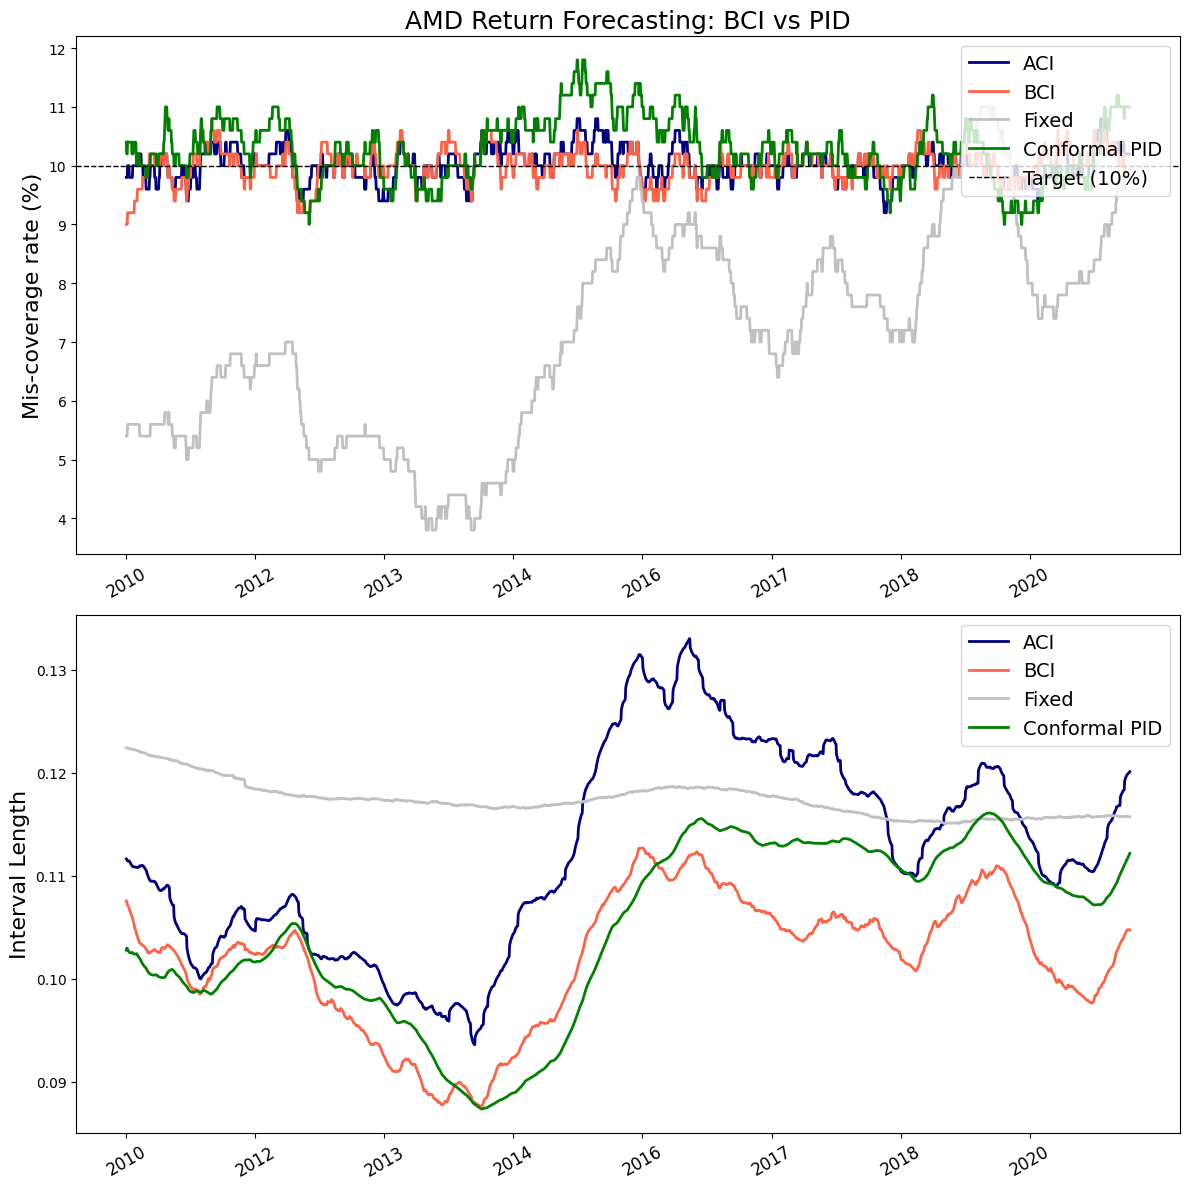

In [15]:
def run_pid_experiment(exp_fixed_result, alpha=0.1, lr=0.05, t_burnin=50):
    y_true = exp_fixed_result['true_y'].values
    y_pred_center = (exp_fixed_result['upper'].values + exp_fixed_result['lower'].values) / 2
    
    scores = np.abs(y_true - y_pred_center)
    
    from pid_methods import quantile_integrator_log
    pid_out = quantile_integrator_log(
        scores=scores, alpha=alpha, lr=lr,
        Csat=10.0, KI=1.0, ahead=1, T_burnin=t_burnin
    )
    
    pid_qs = pid_out['q']
    new_upper = y_pred_center + pid_qs
    new_lower = y_pred_center - pid_qs
    
    df_pid = exp_fixed_result.copy()
    df_pid['upper'] = new_upper
    df_pid['lower'] = new_lower
    df_pid['alpha'] = alpha
    
    is_covered = (df_pid['true_y'] >= df_pid['lower']) & (df_pid['true_y'] <= df_pid['upper'])
    df_pid['beta'] = is_covered.astype(int) 
    
    params_pid = {'method': 'PID', 'task': 'rtfc', 'id': 'PID', 'alpha0': alpha}
    
    return params_pid, df_pid

pid_params, pid_result = run_pid_experiment(exp_fixed.result, alpha=0.1, lr=0.05)

fig = visualize_comparison_with_pid(
    exp_aci.result, exp_bci.result, exp_fixed.result, pid_result,
    exp_aci.params, exp_bci.params, exp_fixed.params, pid_params,
    title="AMD Return Forecasting: BCI vs PID"
)

fig.savefig('AMD_Comparison_with_PID.png', dpi=300)

In [13]:
# Quick Sanity Check for Symmetry
# This proves if "mean" is the correct center
fixed_upper = exp_fixed.result['upper']
fixed_lower = exp_fixed.result['lower']
predicted_center = (fixed_upper + fixed_lower) / 2

# Calculate distance from center to bounds
dist_to_upper = fixed_upper - predicted_center
dist_to_lower = predicted_center - fixed_lower

# Check if they are effectively identical
is_symmetric = np.allclose(dist_to_upper, dist_to_lower, atol=1e-6)

print(f"Is the baseline model symmetric? {is_symmetric}")
# If this prints True, your implementation is 100% consistent with BCI.

Is the baseline model symmetric? True
